# Data Collection

In [ ]:
# Data loading from various sources

import numpy as np # linear algebra
import pandas as pd # data processing
from preprocessor import Preprocessor 
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ----------------- Kaggle Paths -----------------

# # ratings_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.ratings.tsv', delimiter='\t', low_memory=False)
# basics_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.basics.tsv', delimiter='\t', low_memory=False)
# print('IMDb Data Loaded')
# # akas_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.akas.tsv', delimiter='\t', low_memory=False)
# # crew_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.crew.tsv', delimiter='\t', low_memory=False)
# # principals_dataframe = pd.read_csv('/kaggle/input/imdb-data-set-as-on-feb-20th/title.principals.tsv', delimiter='\t', low_memory=False)
# tmdb_dataframe = pd.read_csv('/kaggle/input/tmdb-movies-dataset-2023-930k-movies/TMDB_movie_dataset_v11.csv', low_memory=False)
# print('TMDb Data Loaded')

# rotten_tomatoes_critic_dataframe = pd.read_csv('/kaggle/input/rotten-tomatoes-critic-data-updated-2020/rotten_tomatoes_critic_reviews.csv', low_memory=False)
# rotten_tomatoes_Movies_dataframe = pd.read_csv('/kaggle/input/rotten-tomatoes-critic-data-updated-2020/rotten_tomatoes_movies.csv')
# print('Rotten Tomatoes Data Loaded')

# ----------------- Local Paths -----------------

# ratings_dataframe = pd.read_csv('data/title.ratings.tsv', delimiter='\t', low_memory=False)
basics_dataframe = pd.read_csv('data/title.basics.tsv', delimiter='\t', low_memory=False)
print('IMDb Data Loaded')
# akas_dataframe = pd.read_csv('data/title.akas.tsv', delimiter='\t', low_memory=False)
# crew_dataframe = pd.read_csv('data/title.crew.tsv', delimiter='\t', low_memory=False)
# principals_dataframe = pd.read_csv('data/title.principals.tsv', delimiter='\t', low_memory=False)
tmdb_dataframe = pd.read_csv('data/TMDB_movie_dataset_v11.csv', low_memory=False)
print('TMDb Data Loaded')

rotten_tomatoes_critic_dataframe = pd.read_csv('data/rotten_tomatoes_critic_reviews.csv', low_memory=False)
rotten_tomatoes_Movies_dataframe = pd.read_csv('data/rotten_tomatoes_movies.csv')
print('Rotten Tomatoes Data Loaded')

# print(ratings_dataframe.head())
# print(basics_dataframe.head())
# print(akas_dataframe.head())
# print(crew_dataframe.head())
# print(principals_dataframe.head())
print('Data loaded succefully!')

IMDb Data Loaded
TMDb Data Loaded
Rotten Tomatoes Data Loaded
Data loaded succefully!


In [2]:
# Schema of the Datasets

datasets = {
    'basics':basics_dataframe,
    'TMDb':tmdb_dataframe,
    'rotten tomatoes critic':rotten_tomatoes_critic_dataframe,
    'rotten tomatoes movies':rotten_tomatoes_Movies_dataframe
}

for table, data in datasets.items():
    print(f'''Schema Name: {table},\nVariables: {', '.join(data.columns)},\nDimension: {len(data)} Rows, {len(data.columns)} Columns\n''')

Schema Name: basics,
Variables: tconst, titleType, primaryTitle, originalTitle, isAdult, startYear, endYear, runtimeMinutes, genres,
Dimension: 11464895 Rows, 9 Columns

Schema Name: TMDb,
Variables: id, title, vote_average, vote_count, status, release_date, revenue, runtime, adult, backdrop_path, budget, homepage, imdb_id, original_language, original_title, overview, popularity, poster_path, tagline, genres, production_companies, production_countries, spoken_languages, keywords,
Dimension: 1182360 Rows, 24 Columns

Schema Name: rotten tomatoes critic,
Variables: rotten_tomatoes_link, critic_name, top_critic, publisher_name, review_type, review_score, review_date, review_content,
Dimension: 1130017 Rows, 8 Columns

Schema Name: rotten tomatoes movies,
Variables: rotten_tomatoes_link, movie_title, movie_info, critics_consensus, content_rating, genres, directors, authors, actors, original_release_date, streaming_release_date, runtime, production_company, tomatometer_status, tomatometer_r

In [3]:
# Helper Functions

import re
def convert_letter_to_number(letter_grade):
    grade_mapping = {
        'A+': 100, 'A': 95, 'A-': 90,
        'B+': 87, 'B': 83, 'B-': 80,
        'C+': 77, 'C': 73, 'C-': 70,
        'D+': 67, 'D': 63, 'D-': 60,
        'F': 55
    }
    return grade_mapping.get(letter_grade, None)

def normalize_score(score, max_score):
    try:
        numeric_score = float(score)
        if numeric_score < 0:
            numeric_score * -1;
        if max_score > 0:
            return (numeric_score / max_score) * 100  # Convert to percentage
        elif numeric_score <10:
            return numeric_score * 10;
        else:
            return numeric_score;
    except ValueError:
        return -1

def standardize_scores(value):
    if isinstance(value, str):
        # Check for letter grades
        if re.match(r'^[A-D][+-]?$', value.strip()):
            return convert_letter_to_number(value.strip())
        # Check for numerical scores
        score_match = re.match(r'([0-9\.]+)/([0-9]+)', value)
        if score_match:
            score, max_score = score_match.groups()
            return normalize_score(score, float(max_score))
    return None  # for any other formats or NaN values

# Data Pre-Processing

## 1. Handling Missing and Irrelevant data

In [4]:
# Dropping irrelevant columns

tmdb_redundant_cols = ['backdrop_path','homepage','keywords', 'overview','poster_path', 'tagline']
rtc_redundant_cols = ['critic_name', 'top_critic', 'review_type', 'review_date', 'review_content']
rtm_redundant_cols = ['critics_consensus']

existing_cols = [col for col in tmdb_dataframe.columns if col in tmdb_redundant_cols]
tmdb_dataframe = tmdb_dataframe.drop(columns=existing_cols)

existing_cols = [col for col in rotten_tomatoes_critic_dataframe.columns if col in rtc_redundant_cols]
rotten_tomatoes_critic_dataframe = rotten_tomatoes_critic_dataframe.drop(columns=existing_cols)

existing_cols = [col for col in rotten_tomatoes_Movies_dataframe.columns if col in rtm_redundant_cols]
rotten_tomatoes_Movies_dataframe = rotten_tomatoes_Movies_dataframe.drop(columns=existing_cols)

In [5]:
# Transforming object data type to numeric data type
metrics = ['tomatometer_rating', 'audience_rating', 'revenue', 'runtime_y', 'budget','popularity', 'log_capped_revenue']
for key, dataset in datasets.items():
    for col in dataset.columns:
        if col in metrics:
            dataset[col] = pd.to_numeric(dataset[col])

In [6]:
# Handling Missing Data

#Filter required columns fromt the data sets
revenue_data = tmdb_dataframe[['revenue', 'budget','imdb_id','release_date','title']].copy()
genre_data = basics_dataframe[['tconst', 'genres']].copy()
release_year_data = tmdb_dataframe[['release_date','imdb_id']].copy()
movies_df = rotten_tomatoes_Movies_dataframe[['movie_title','rotten_tomatoes_link','tomatometer_rating', 'audience_rating']].copy()
rtc = rotten_tomatoes_critic_dataframe[['rotten_tomatoes_link','review_score']].copy()

# Handling Irrelevant Values (eg: revenue or budget shouldn't be 0)
# Dropping off the rows with < 0 revenue, as Imputation would be highly inconsistence in this case
# as missing values >>> available values
revenue_data = revenue_data[revenue_data['revenue'] > 0] # Revenue should be greater than 0

# Using Imputation with mean value to calculate missing budget values
revenue_data['budget'] = revenue_data['budget'].replace(0, np.nan)
mean_budget = revenue_data['budget'].dropna().mean()
revenue_data['budget'] = revenue_data['budget'].fillna(mean_budget)

# Handling Data Format

revenue_data['release_date'] = pd.to_datetime(revenue_data['release_date'])

# critic rating (review score) has data in mixed format and is not usable
# transforming it to uniform format and numeric form using helper functions defined above

print('Data Before cleaning')
print(rtc.head())

# cleaning
rs = rtc['review_score'].copy()
for i in range(0, len(rs)):
    rs[i] = standardize_scores(rs[i])
rtc['review_score'] = rs
rtc = rtc.dropna()
rtc['review_score'] = pd.to_numeric(rtc['review_score'])

print('Data after cleaning')
print(rtc.head())
print(rtc['review_score'].dtype)
critics_df = rtc[['rotten_tomatoes_link','review_score']].copy()

Data Before cleaning
  rotten_tomatoes_link review_score
0            m/0814255          NaN
1            m/0814255          NaN
2            m/0814255          NaN
3            m/0814255        3.5/5
4            m/0814255          NaN
Data after cleaning
  rotten_tomatoes_link  review_score
3            m/0814255          70.0
6            m/0814255          25.0
7            m/0814255          70.0
8            m/0814255          83.0
9            m/0814255          60.0
float64


## 2. Handling Outliers

In [7]:
# Applying the log transformation safely
revenue_data['log_revenue'] = np.log(revenue_data['revenue'])
revenue_data['log_budget'] = np.log(revenue_data['budget'])

# Capping
cap_threshold = revenue_data['log_revenue'].quantile(0.99)  # Cap at the 99th percentile
revenue_data['capped_log_revenue'] = np.where(revenue_data['log_revenue'] > cap_threshold, cap_threshold, revenue_data['log_revenue'])

## 3. Build sets for EDA

In [8]:
# Calculations and Building Merged Data Sets for EDA

# Deriving Year from Release Date
release_year_data['year'] = pd.to_datetime(release_year_data['release_date'], errors='coerce').dt.year

# Merge datasets on 'tconst'
release_year_genre_data = pd.merge(genre_data, release_year_data, left_on='tconst', right_on='imdb_id', how='inner')

movies_df['rotten_tomatoes_link'] = movies_df['rotten_tomatoes_link'].str.strip().str.lower()
critics_df['rotten_tomatoes_link'] = critics_df['rotten_tomatoes_link'].str.strip().str.lower()

# Merging movies_df and critics_df on 'rotten_tomatoes_link'
merged_df = pd.merge(movies_df, critics_df, on='rotten_tomatoes_link', how='inner')

# Merging movies_df, critics_df and revenue_data on title
merged_df = pd.merge(merged_df, revenue_data, left_on='movie_title', right_on='title', how='inner')

# Calculate average critics' rating
critics_avg = merged_df.groupby('rotten_tomatoes_link')['review_score'].mean().reset_index()
critics_avg.columns = ['rotten_tomatoes_link', 'avg_critics_rating']

# Merge this back into the merged_df
merged_df = pd.merge(merged_df, critics_avg, on='rotten_tomatoes_link', how='left')

# Exploratory Data Analysis (EDA)

## 1. Revenue Distribution Analysis

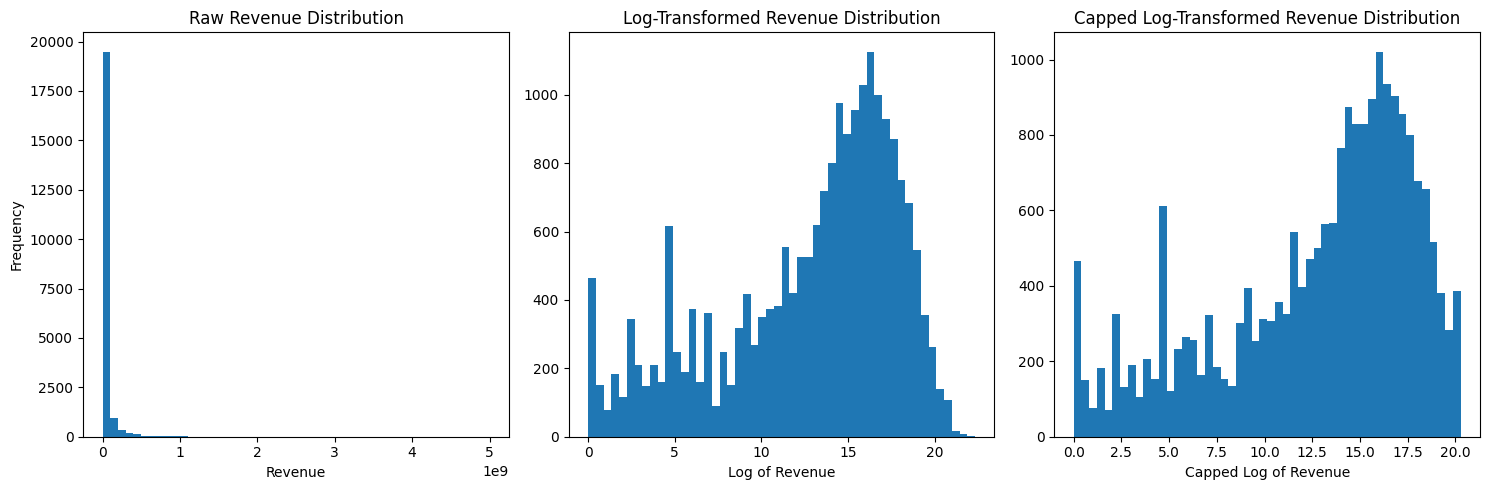

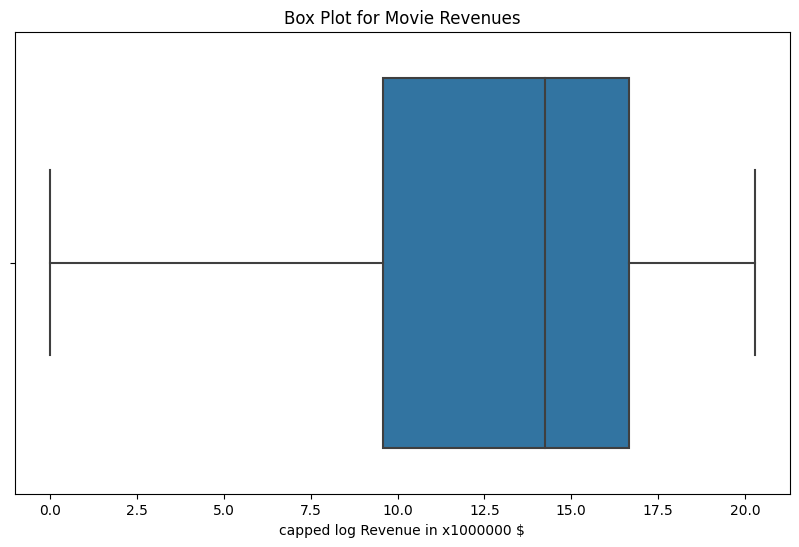

In [10]:
# Revenue Distribution Analysis

plt.figure(figsize=(15, 5))

# Raw Revenue
plt.subplot(1, 3, 1)
plt.hist(revenue_data['revenue'], bins=50)
plt.title('Raw Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

# Log-Transformed Revenue
plt.subplot(1, 3, 2)
plt.hist(revenue_data['log_revenue'], bins=50)
plt.title('Log-Transformed Revenue Distribution')
plt.xlabel('Log of Revenue')

# Capped Log-Transformed Revenue
plt.subplot(1, 3, 3)
plt.hist(revenue_data['capped_log_revenue'], bins=50)
plt.title('Capped Log-Transformed Revenue Distribution')
plt.xlabel('Capped Log of Revenue')

plt.tight_layout()
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=revenue_data['capped_log_revenue'])
plt.title('Box Plot for Movie Revenues')
plt.xlabel('capped log Revenue in x1000000 $')
plt.show()


## 2. Budget vs. Revenue Analysis

Correlation coefficient between budget and revenue: 0.642478778222043


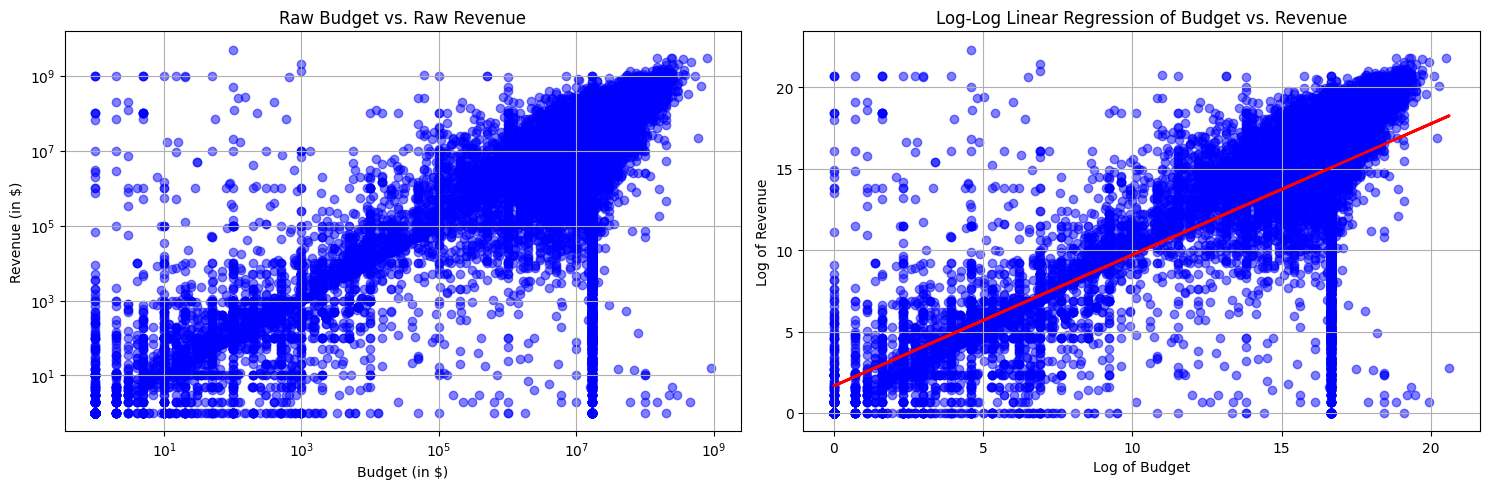

In [9]:
# Budget vs. Revenue Analysis 

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.scatter(revenue_data['budget'], revenue_data['revenue'], alpha=0.5, color='blue')
plt.title('Raw Budget vs. Raw Revenue')
plt.xlabel('Budget (in $)')
plt.ylabel('Revenue (in $)')
plt.grid(True)
plt.xscale('log')  # Using log scale for better visualization
plt.yscale('log')  # Log scale on y-axis

correlation = revenue_data['budget'].corr(revenue_data['revenue'])
print(f"Correlation coefficient between budget and revenue: {correlation}")

# Linear Regression
model = LinearRegression()
model.fit(revenue_data[['log_budget']], revenue_data['log_revenue'])  # X needs to be 2D array hence double brackets

# Plotting regression line
plt.subplot(1, 2, 2)
plt.scatter(revenue_data['log_budget'], revenue_data['log_revenue'], alpha=0.5, color='blue')
plt.plot(revenue_data['log_budget'], model.predict(revenue_data[['log_budget']]), color='red', linewidth=2)
plt.title('Log-Log Linear Regression of Budget vs. Revenue')
plt.xlabel('Log of Budget')
plt.ylabel('Log of Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Genre Popularity Over Time

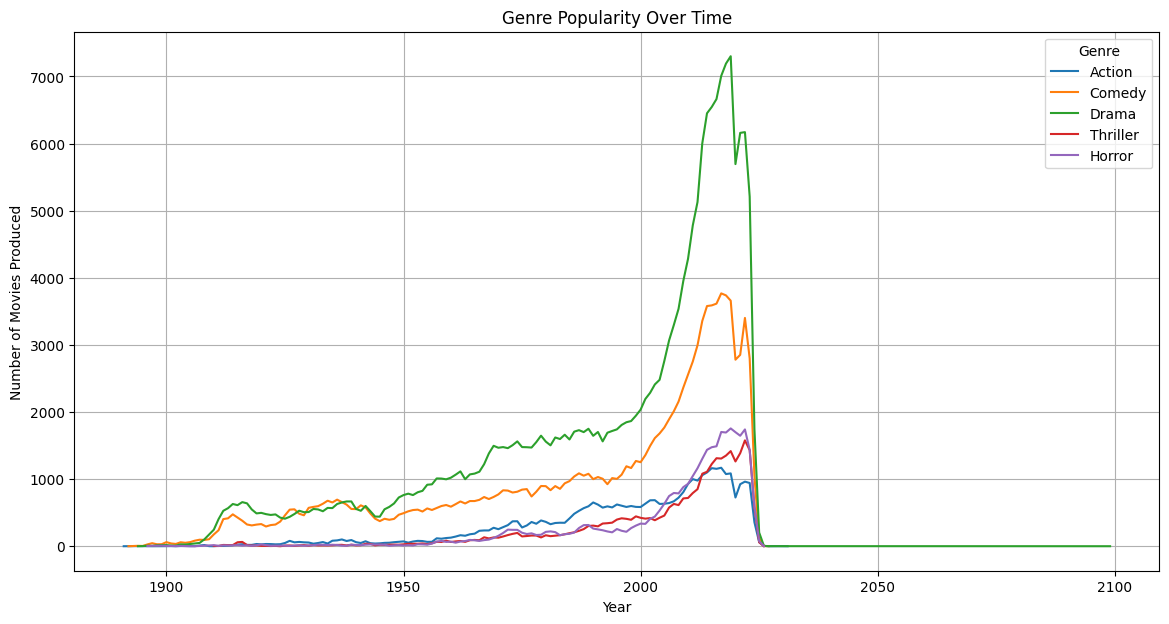

In [96]:
# Genre Popularity Over Time 

# Explode the 'genres' column into multiple rows
release_year_genre_data['genres'] = release_year_genre_data['genres'].str.split(',')
release_year_genre_data = release_year_genre_data.explode('genres')

# Group by year and genre, then count the number of movies
genre_popularity = release_year_genre_data.groupby(['year', 'genres']).size().reset_index(name='counts')

# Filter select genres for clarity in visualization
selected_genres = ['Action', 'Comedy', 'Drama', 'Thriller', 'Horror']
filtered_data = genre_popularity[genre_popularity['genres'].isin(selected_genres)]

plt.figure(figsize=(14, 7))
for genre in selected_genres:
    subset = filtered_data[filtered_data['genres'] == genre]
    plt.plot(subset['year'], subset['counts'], marker='', label=genre)

plt.title('Genre Popularity Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Movies Produced')
plt.legend(title='Genre')
plt.grid(True)
plt.show()

## 4. Impact of Ratings on Revenue

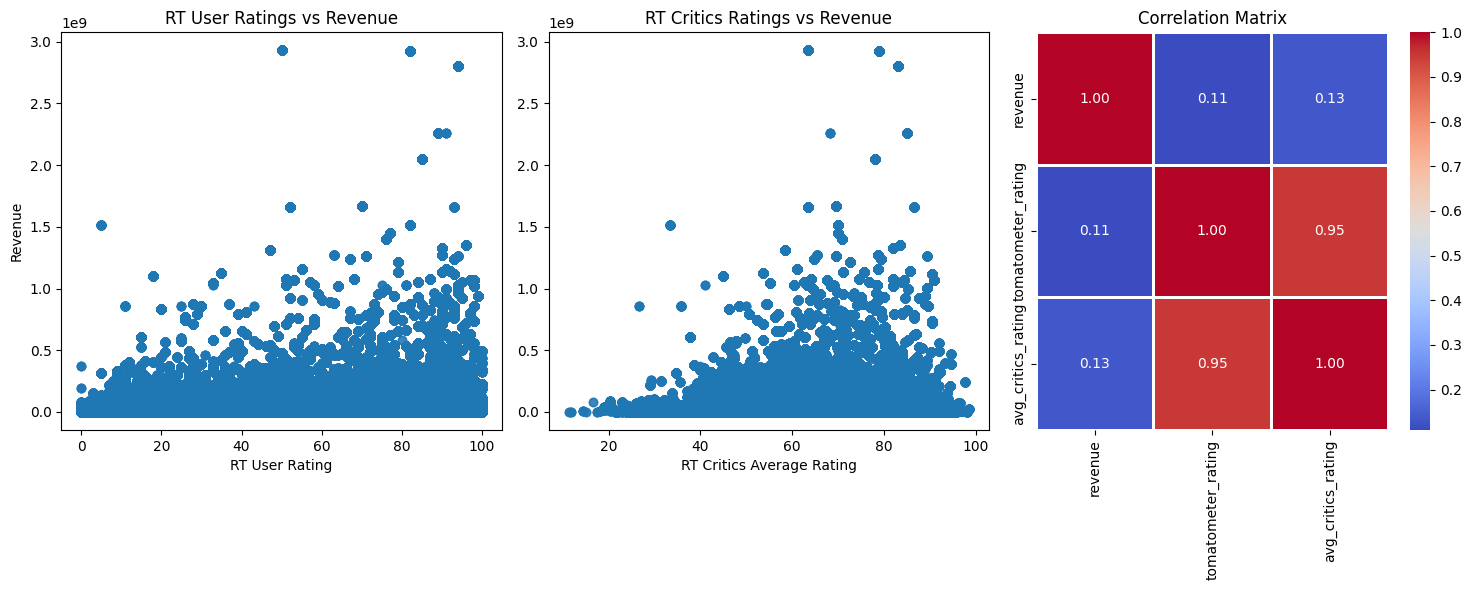

In [97]:
# Impact of Ratings on Revenue

plt.figure(figsize=(15, 6))

# Scatter plot for User Ratings vs Revenue
plt.subplot(1, 3, 1)
plt.scatter(merged_df['tomatometer_rating'], merged_df['revenue'], alpha=0.5)
plt.title('RT User Ratings vs Revenue')
plt.xlabel('RT User Rating')
plt.ylabel('Revenue')

# Scatter plot for Critics Ratings vs Revenue
plt.subplot(1, 3, 2)
plt.scatter(merged_df['avg_critics_rating'], merged_df['revenue'], alpha=0.5)
plt.title('RT Critics Ratings vs Revenue')
plt.xlabel('RT Critics Average Rating')

# Selecting relevant columns for the correlation matrix
correlation_matrix = merged_df[['revenue', 'tomatometer_rating', 'avg_critics_rating']].corr()

# Plotting the correlation matrix
plt.subplot(1, 3, 3)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 5. Skewness and Outliers in Key Metrics

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


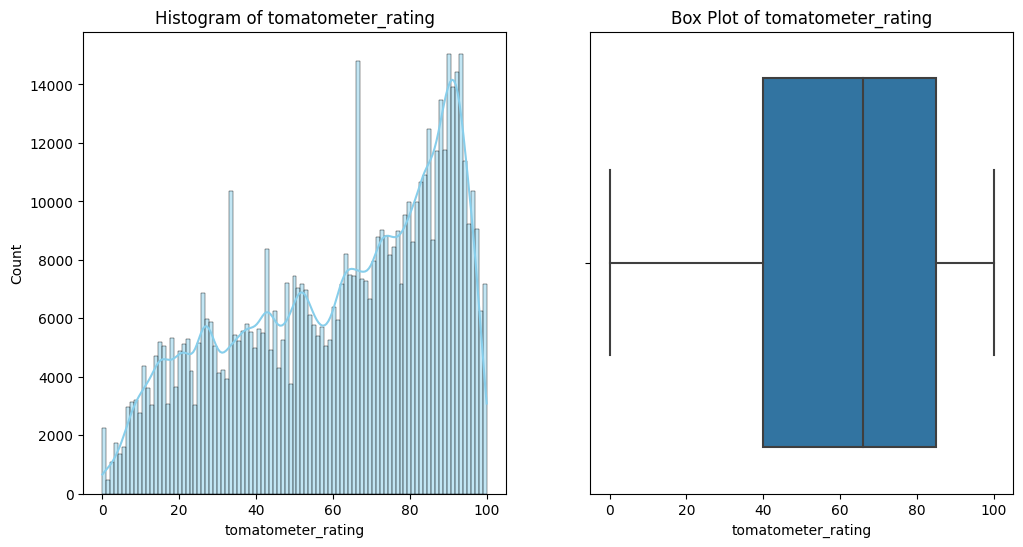

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


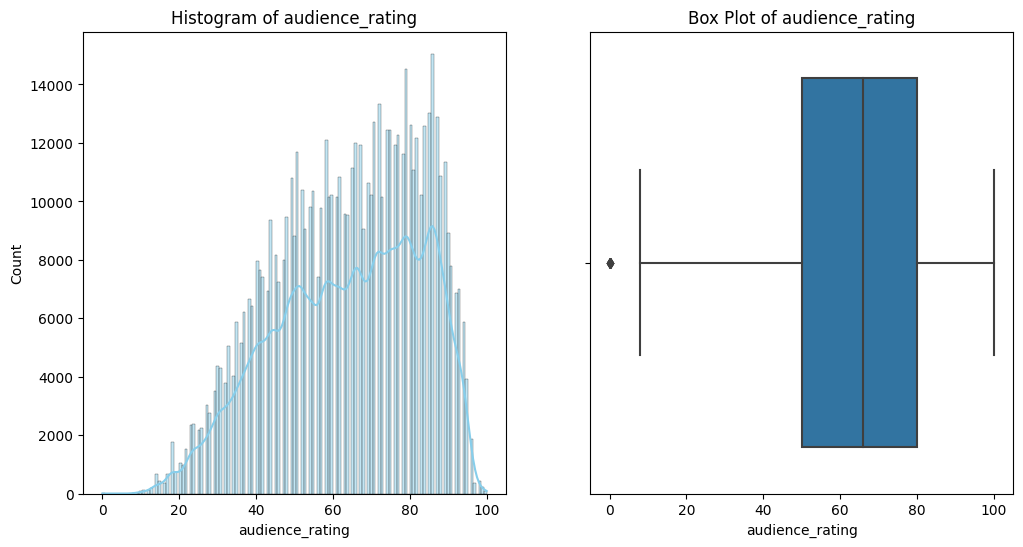

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


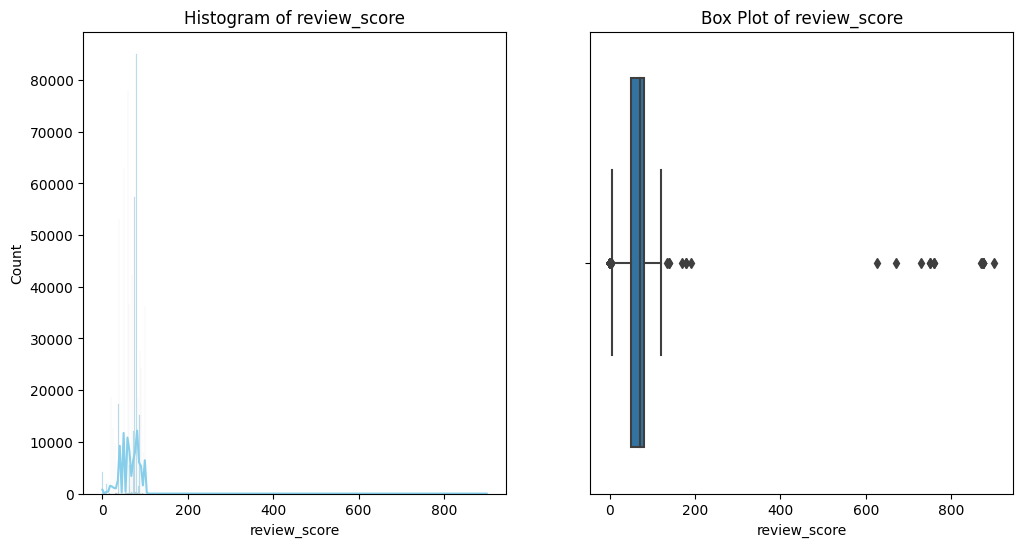

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


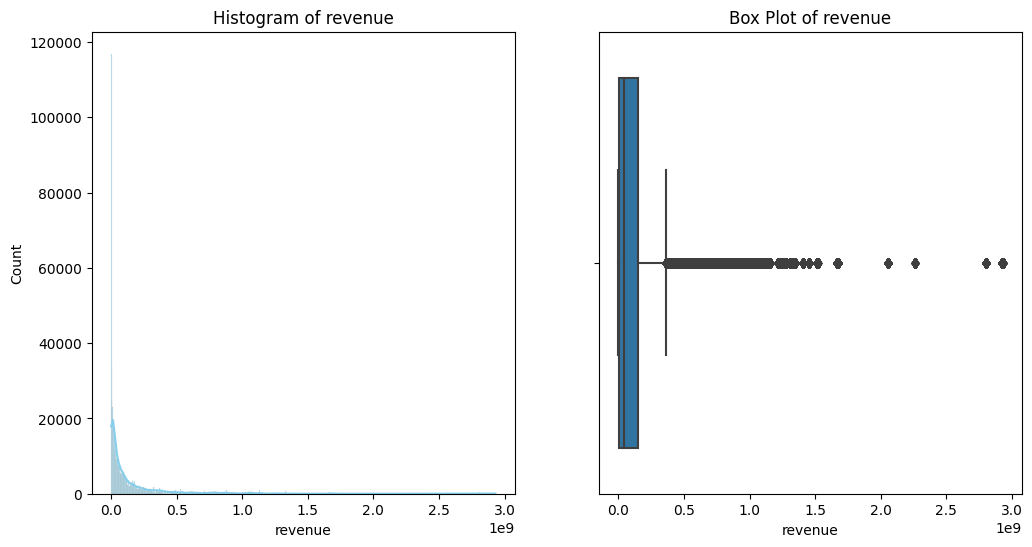

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


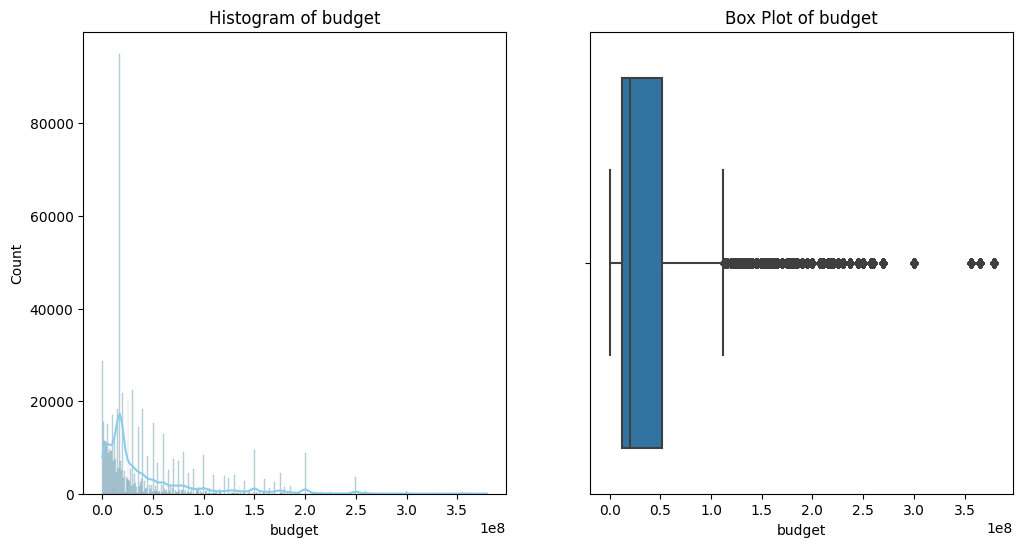

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


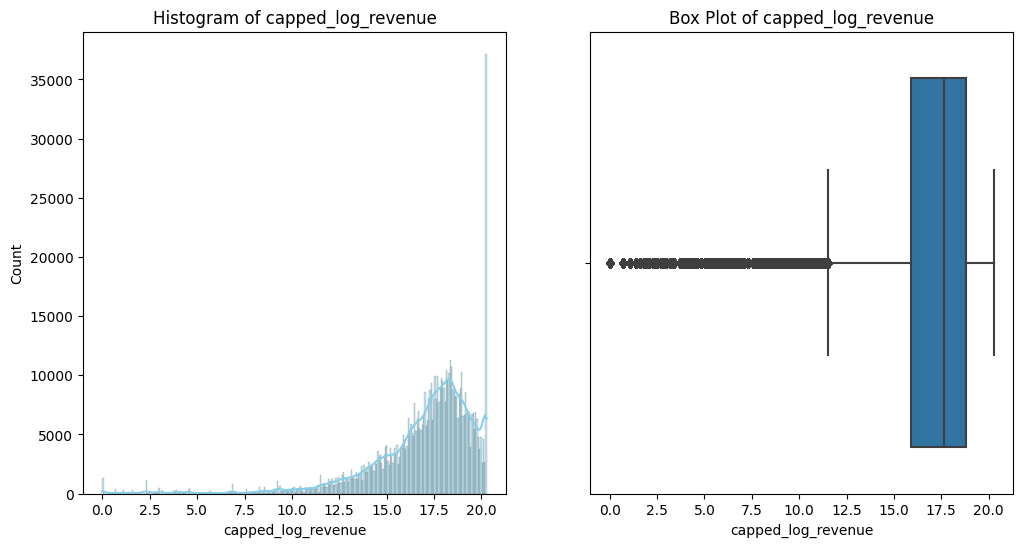

In [98]:
# Skewness and Outliers in Key Metrics

metrics = ['tomatometer_rating', 'audience_rating','review_score', 'revenue', 'budget', 'capped_log_revenue']
# Replace infinite values with NaN for the entire DataFrame before processing individual metrics
merged_df.replace([np.inf, -np.inf], np.nan, inplace=True)

for metric in metrics:
    # Convert data to numeric, coerce errors to NaN, and drop NaN values
    merged_df[metric] = pd.to_numeric(merged_df[metric], errors='coerce')
    merged_df.dropna(subset=[metric], inplace=True)  # Drop NaNs from specific metric column

    plt.figure(figsize=(12, 6))
    
    # Create histogram
    plt.subplot(1, 2, 1)
    sns.histplot(merged_df[metric], kde=True, color='skyblue')
    plt.title(f'Histogram of {metric}')
    
    # Create boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=merged_df[metric])
    plt.title(f'Box Plot of {metric}')
    
    plt.show()

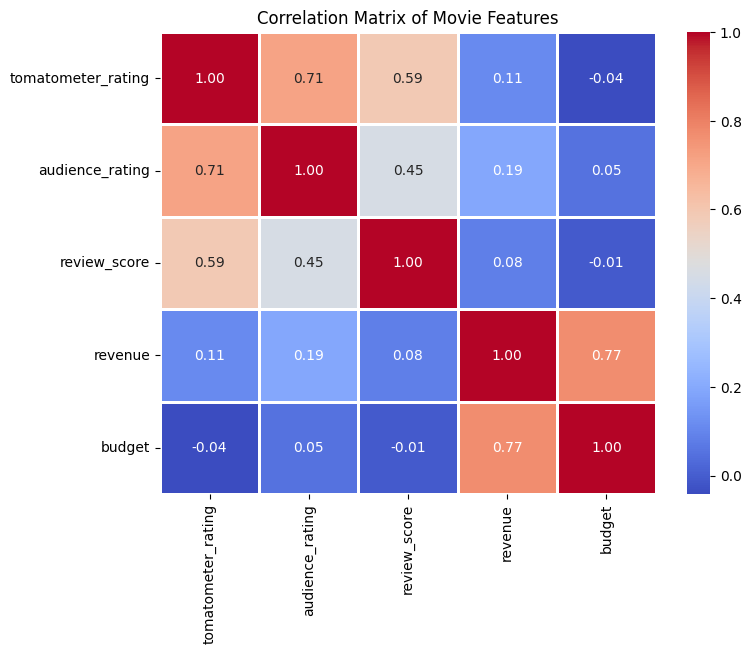

In [99]:
# Multicollinearity in Movie Features

cols = ['tomatometer_rating', 'audience_rating','review_score', 'revenue', 'budget']
merged_df.dropna(subset=cols, inplace=True)

corr_matrix = merged_df[cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title("Correlation Matrix of Movie Features")
plt.show()

In [101]:
print(revenue_data['release_date'].dtype)

object


## 6. Release Timing and Revenue Performance

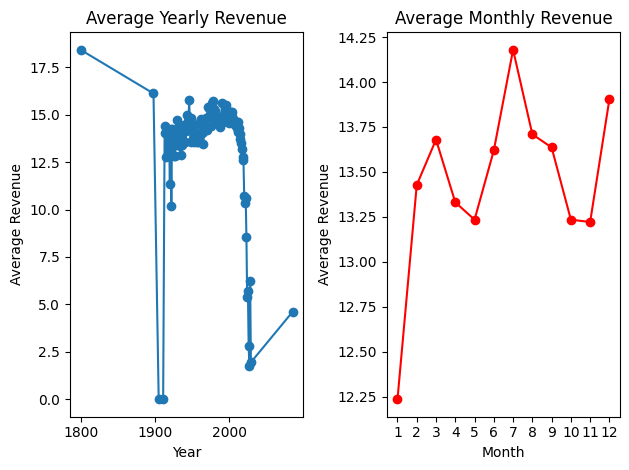

In [103]:
# Release Timing and Revenue Performance

revenue_data = revenue_data.dropna(subset=['release_date'])
revenue_data['year'] = revenue_data['release_date'].dt.year
revenue_data['month'] = revenue_data['release_date'].dt.month

# Group by month and calculate average revenue
monthly_revenue = revenue_data.groupby('month')['log_revenue'].mean().reset_index()

# Group by year and calculate average revenue
yearly_revenue = revenue_data.groupby('year')['log_revenue'].mean().reset_index()

# Yearly revenue trend
plt.subplot(1, 2, 1)
plt.plot(yearly_revenue['year'], yearly_revenue['log_revenue'], marker='o')
plt.title('Average Yearly Revenue')
plt.xlabel('Year')
plt.ylabel('Average Revenue')

# Monthly revenue trend
plt.subplot(1, 2, 2)
plt.plot(monthly_revenue['month'], monthly_revenue['log_revenue'], marker='o', color='red')
plt.title('Average Monthly Revenue')
plt.xlabel('Month')
plt.xticks(range(1, 13))  # Ensure all months are shown
plt.ylabel('Average Revenue x1000000 $')

plt.tight_layout()
plt.show()

# Feature Engineering

In [ ]:
# Helper Functions

def is_festive(month):
    if month in [1, 6, 7, 10, 11, 12]:
        return 'True'
    else:
        return 'False'

## A. Creating New Features